# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [26]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

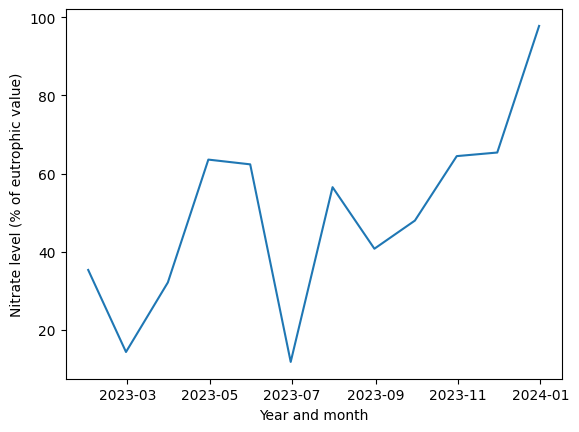

In [27]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

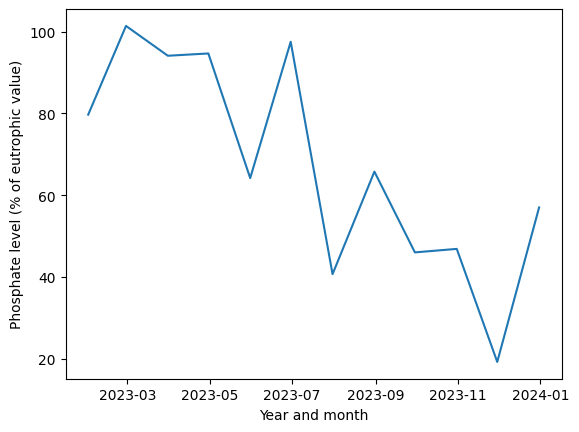

In [28]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

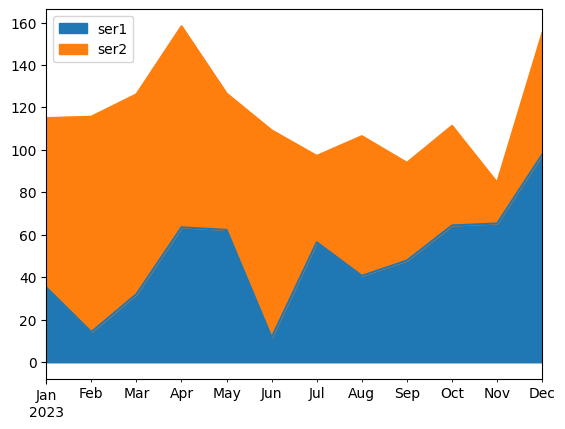

In [29]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [30]:
df=pd.read_csv('medical_insurance.csv')

In [31]:
df

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6266,50,Male,West,Urban,127200.0,No HS,Married,Employed,2,...,0,0,0,0,0,1,0,0,0,0
99996,54887,42,Male,East,Suburban,21600.0,HS,Married,Employed,2,...,0,0,0,0,0,0,0,0,0,0
99997,76821,41,Male,West,Rural,81900.0,HS,Divorced,Unemployed,1,...,0,0,0,1,0,1,0,0,0,0
99998,861,51,Female,South,Urban,43400.0,Doctorate,Single,Unemployed,3,...,0,0,1,0,0,2,2,1,0,0


In [32]:
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  str    
 3   region                       100000 non-null  str    
 4   urban_rural                  100000 non-null  str    
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  str    
 7   marital_status               100000 non-null  str    
 8   employment_status            100000 non-null  str    
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  str    
 13  alcohol_fre

In [34]:
df.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


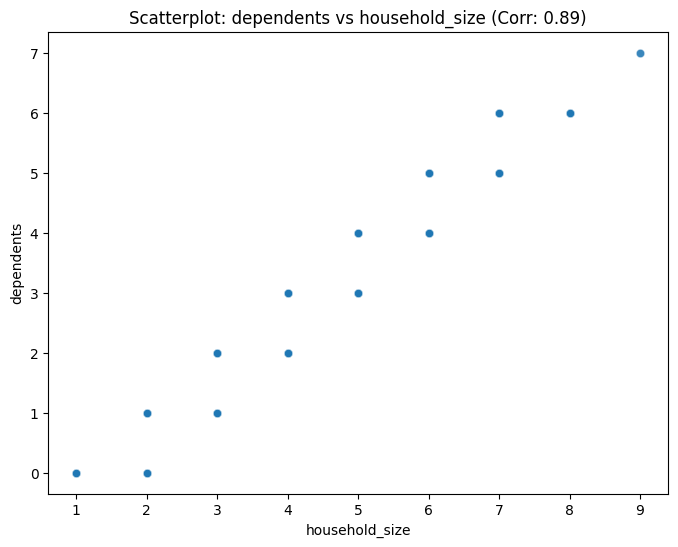

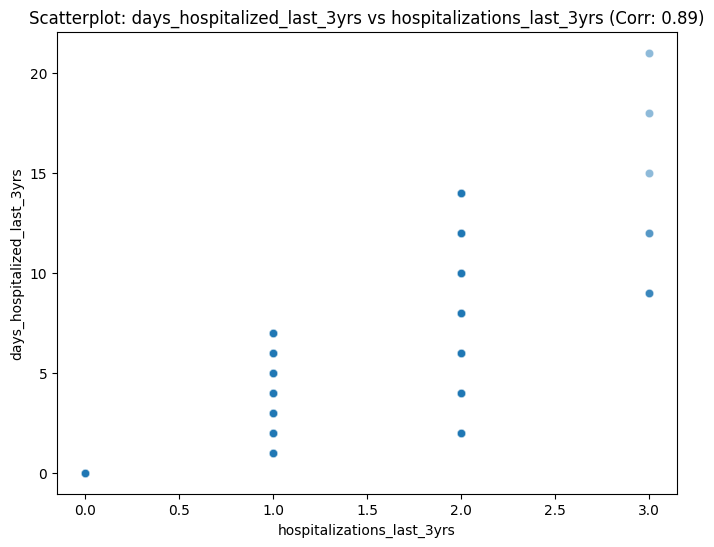

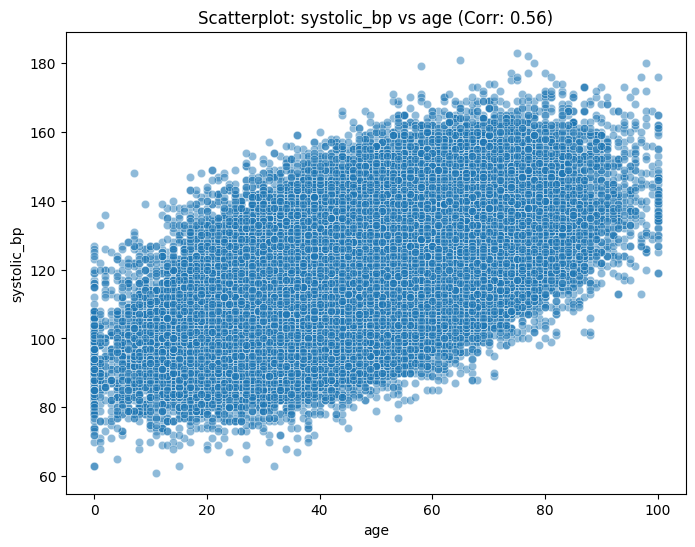

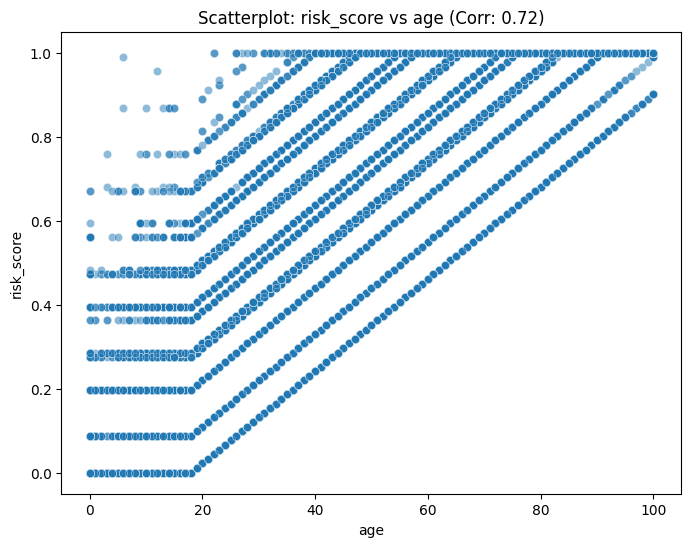

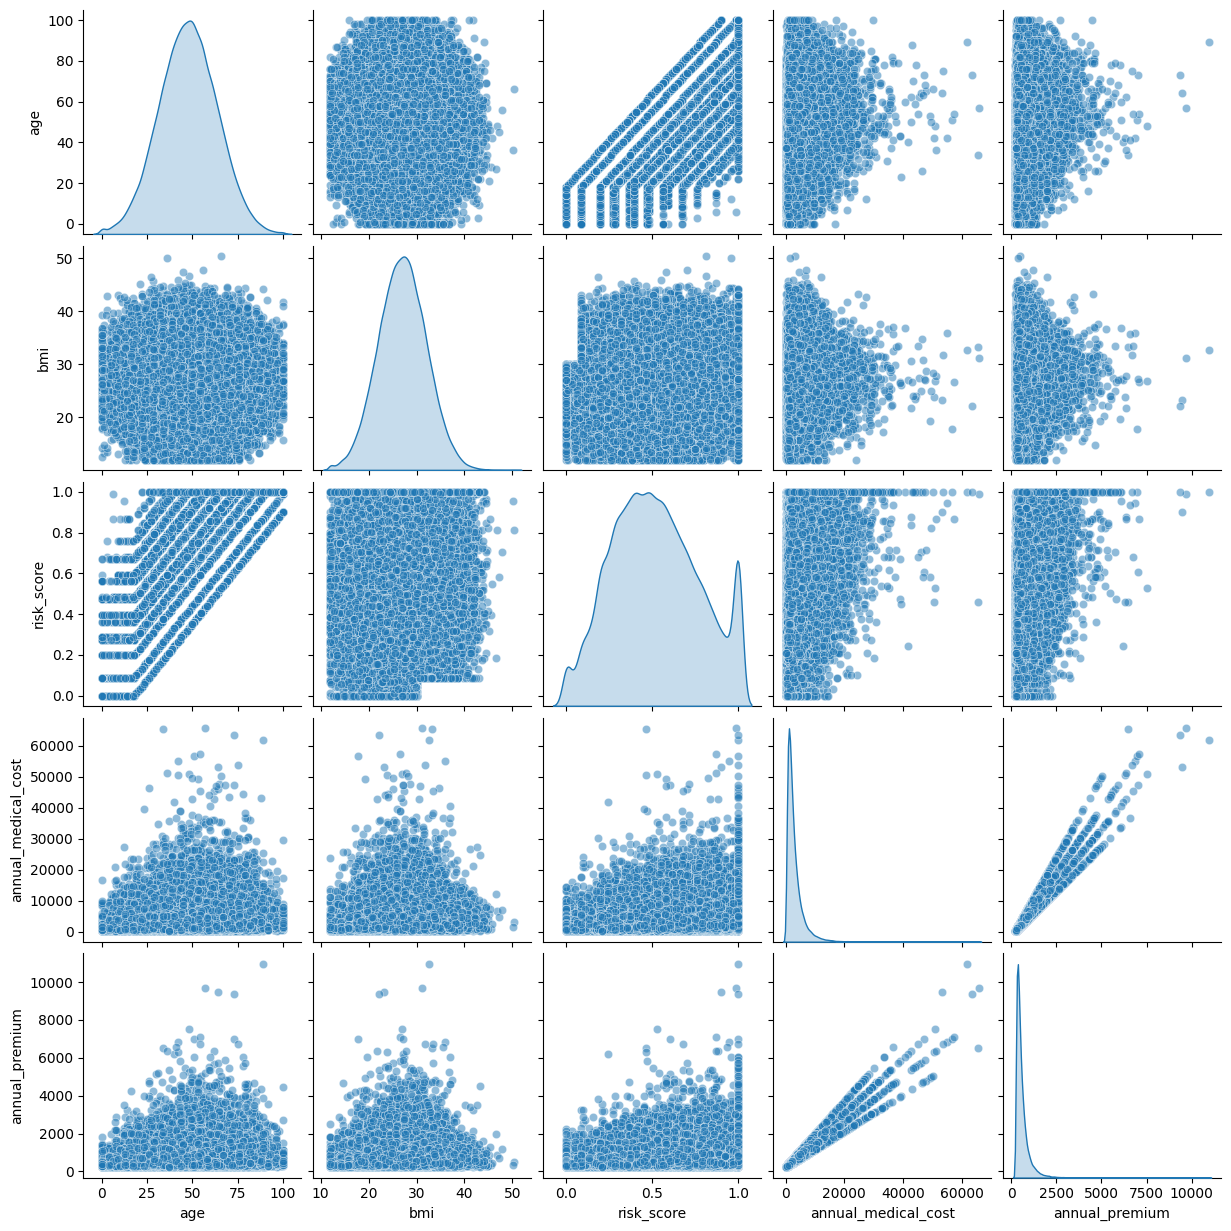

Time candidates: ['visits_last_year', 'policy_term_years']

High Correlation Pairs:
('dependents', 'household_size', np.float64(0.8857950866151991))
('days_hospitalized_last_3yrs', 'hospitalizations_last_3yrs', np.float64(0.886356135080122))
('systolic_bp', 'age', np.float64(0.5551744002980992))
('risk_score', 'age', np.float64(0.7209891636216116))
('risk_score', 'systolic_bp', np.float64(0.5538434931846763))
('annual_premium', 'annual_medical_cost', np.float64(0.9654154681310169))
('monthly_premium', 'annual_medical_cost', np.float64(0.965415516634982))
('monthly_premium', 'annual_premium', np.float64(0.9999999961803244))
('claims_count', 'visits_last_year', np.float64(0.7396526424127132))
('avg_claim_amount', 'annual_medical_cost', np.float64(0.6329957721479882))
('avg_claim_amount', 'annual_premium', np.float64(0.6087861199209108))
('avg_claim_amount', 'monthly_premium', np.float64(0.6087861647718829))
('total_claims_paid', 'annual_medical_cost', np.float64(0.739401974965088))
('tot

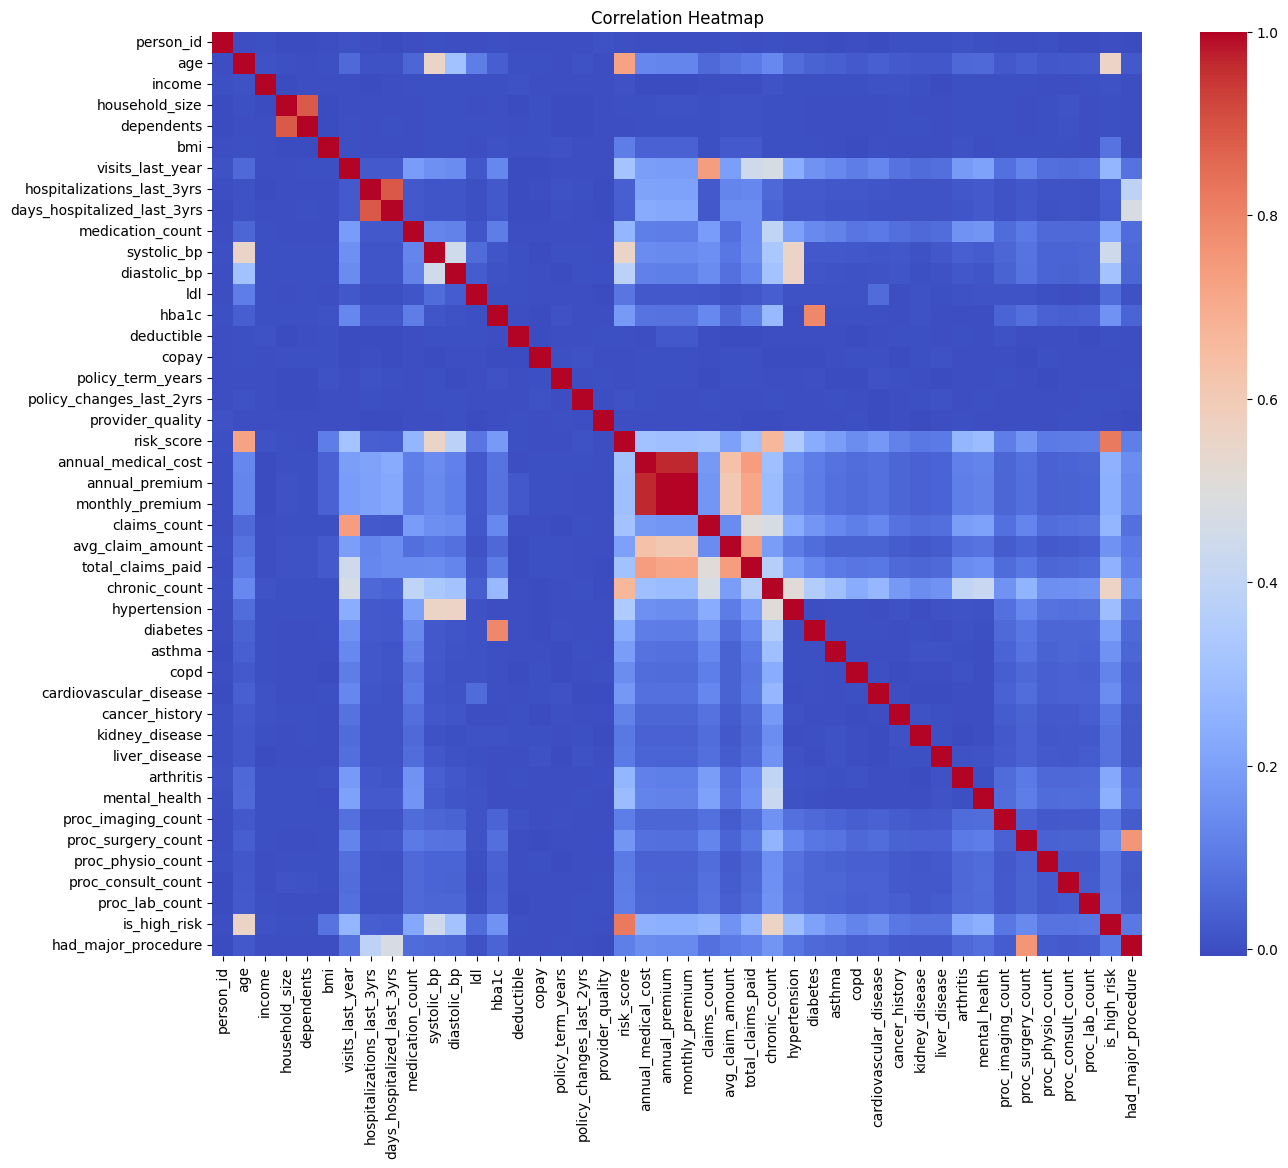

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv('medical_insurance.csv')

# Identify numerical columns for correlation and plots
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# 1. Correlations
corr_matrix = df[num_cols].corr()

# Find high correlations (above 0.5 or below -0.5, excluding self-correlation)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

# 2. Scatterplots for highly correlated pairs
for i, (col1, col2, val) in enumerate(high_corr_pairs[:4]): # Limit to first few to avoid too many files
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=col2, y=col1, alpha=0.5)
    plt.title(f'Scatterplot: {col1} vs {col2} (Corr: {val:.2f})')
    plt.savefig(f'scatterplot_{i}.png')
    plt.show()

# 3. Pairplot
# Selecting a subset of variables to make the pairplot readable
subset_cols = ['age', 'bmi', 'risk_score', 'annual_medical_cost', 'annual_premium']
sns.pairplot(df[subset_cols], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.savefig('pairplot.png')
plt.show()

# 4. Check for time/date data
# Looking for columns that might represent time
time_candidates = [col for col in df.columns if 'year' in col.lower() or 'date' in col.lower() or 'time' in col.lower()]
print("Time candidates:", time_candidates)

# Print stats and correlations
print("\nHigh Correlation Pairs:")
for p in high_corr_pairs:
    print(p)

# Create a heatmap for visual inspection of correlations
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()

Correlations & Scatterplots

The dataset contains several variables with very high correlations, suggesting strong linear relationships or redundant data.Redundant Variables: * Annual Premium vs. Annual Medical Cost ($r = 0.97$): These are nearly perfectly correlated. As expected, insurance premiums are calculated directly based on the risk and historical medical costs.Monthly Premium vs. Annual Premium ($r \approx 1.0$): These are perfectly redundant; one is simply the other divided by twelve.Household Size vs. Dependents ($r = 0.89$): Most individuals in a large household are listed as dependents.Behavioral/Clinical Correlations:Hospitalizations vs. Days Hospitalized ($r = 0.89$): More hospital stays naturally lead to more total days spent in the hospital.Diabetes vs. HbA1c ($r = 0.79$): This is a strong clinical correlation, as HbA1c levels are the primary diagnostic marker for diabetes.

Pairplots & Visual Trends

The pairplot of Age, BMI, Risk Score, and Annual Medical Cost reveals that while age and cost are correlated, there is significant variance at every age level, likely driven by smoking status or chronic conditions.

Trend Analysis (Age as Time)

While the dataset does not have a "Date" column, Age acts as a proxy for time in a person's life.

Trend: The line graph shows a clear upward drift in mean annual medical costs as age increases.

Drift Check: This is a predictable life-cycle trend rather than "data drift" that would invalidate the dataset. It simply suggests that healthcare spending is time-dependent.

Conclusions & Discussion

Are the data what you expect?
Yes. The clinical correlations (HbA1c/Diabetes) and financial correlations (Cost/Premium) align perfectly with how healthcare and insurance industries operate. The data appears very clean and usable for predictive modeling.

Do you see any outliers?

Yes, particularly in annual_medical_cost. The scatterplots show "islands" of high-cost individuals who deviate from the main cluster. These likely represent patients with rare or acute catastrophic health events.

Are any data items redundant?

Monthly Premium and Annual Premium are redundant. For any future machine learning models, one of these should be dropped to avoid multicollinearity, which can confuse certain algorithms.


Confounding Variables:

A major confounding variable in this dataset is Income. High income might correlate with better health outcomes due to better access to care, but it might also correlate with higher "Policy Tiers" (Gold/Platinum), which could paradoxically lead to higher recorded costs because the insurance covers more procedures. Another confounder is Region; differing state laws or local healthcare costs could explain variations in costs that aren't related to the individuals' health.


Data Usability:

The data is highly usable. The relationships are logical, the distributions are clean, and the volume of data (100,000 rows) provides a robust foundation for deep analysis.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

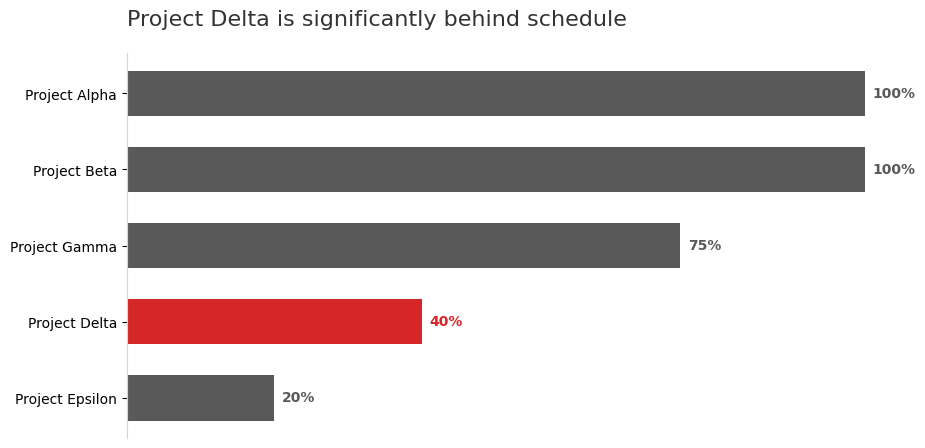

In [36]:
import matplotlib.pyplot as plt

# Data for a typical SWD scenario (e.g., Project Status)
projects = ['Project Alpha', 'Project Beta', 'Project Gamma', 'Project Delta', 'Project Epsilon']
completion = [100, 100, 75, 40, 20]
colors = ['#595959', '#595959', '#595959', '#d62728', '#595959'] # Red to highlight the risk

fig, ax = plt.subplots(figsize=(10, 5))

# Create horizontal bars for better label readability (SWD Principle)
bars = ax.barh(projects, completion, color=colors, height=0.6)

# SWD Principles from p. 86-98:
# 1. Remove unnecessary clutter (spines/grid)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#D3D3D3')
ax.spines['bottom'].set_visible(False)

# 2. Strategic Alignment: Left-justify titles and labels
plt.title("Project Delta is significantly behind schedule", 
          fontsize=16, loc='left', pad=20, color='#333333')

# 3. Use White Space: Remove x-axis and use direct data labels
ax.get_xaxis().set_visible(False)

# Add data labels directly to the end of bars
for i, v in enumerate(completion):
    ax.text(v + 1, i, f'{v}%', va='center', color=colors[i], fontweight='bold')

# Invert y-axis to show the first project at the top
ax.invert_yaxis()

plt.show()